# Demand-Based Pricing with Seasonal Adjustment
### A practical pricing workflow for analysts, operators, and mildly suspicious spreadsheets

This notebook is designed to be useful before it is clever.

It takes historical price and volume data, estimates a demand curve, applies monthly seasonal factors, and produces forward price recommendations. If you do not have a file ready, it runs on simulated data so you can see the workflow without first negotiating with a spreadsheet that has clearly seen things.

**What this notebook does:**
1. Accepts your own sales data or runs on built-in simulated data
2. Estimates a demand curve from historical price and volume
3. Applies seasonal adjustment factors to project forward demand
4. Computes profit-maximizing price recommendations by period
5. Exports the results to Excel for review, sharing, or the traditional ritual of forwarding things to someone who asks, "Can we see this in Excel?"

**Who this is for:** Pricing analysts, commercial operators, and business teams who want a transparent, editable model without pretending every problem requires a neural network and a dramatic slide deck.

**Requirements:** `pandas`, `numpy`, `matplotlib`, `scipy`

This is also an example of the kind of reusable business workflow TaskMarket is being built to support: practical analytical tools that can be packaged, tested, improved, and eventually operated by people or agents.

---
> **How to use your own data:** Set `USE_SIMULATED_DATA = False` in the next cell and point `FILE_PATH` to your file.  
> Supported formats: `.csv`, `.xlsx`, `.xls`, `.json`, `.parquet`  
> Required columns: a **date** column, a **price** column, and a **quantity/units sold** column.  
> Column names are detected automatically. You will still want to inspect them, because trusting column names blindly is how civilization gets quarterly reforecasts.

In [1]:
# ============================================================
#  CONFIGURATION  -  edit this cell only
# ============================================================

USE_SIMULATED_DATA = True   # Set False to use your own file

FILE_PATH = "your_sales_data.csv"   # Path to your file (ignored if USE_SIMULATED_DATA = True)

# Optional: override detected column names (leave as None to auto-detect)
DATE_COL     = None   # e.g. "week_ending"
PRICE_COL    = None   # e.g. "avg_price_usd"
QUANTITY_COL = None   # e.g. "units_sold"

# Seasonal adjustment - monthly multipliers (1.0 = no change)
# Adjust these based on your business knowledge
SEASONAL_FACTORS = {
    1:  0.82,   # January   - post-holiday demand dip
    2:  0.85,   # February
    3:  0.93,   # March
    4:  0.97,   # April
    5:  1.00,   # May
    6:  1.04,   # June
    7:  1.08,   # July     - mid-year refresh cycle
    8:  1.12,   # August
    9:  1.10,   # September
    10: 1.05,   # October
    11: 1.18,   # November  - pre-holiday build
    12: 1.22,   # December  - peak season
}

# Pricing parameters
COST_PER_UNIT   = 280.00   # Your unit cost
TARGET_MARGIN   = 0.20     # Minimum acceptable gross margin (20%)
PRICE_FLOOR     = COST_PER_UNIT * (1 + TARGET_MARGIN)
PRICE_CEILING   = 700.00   # Maximum price to recommend

# Forecast horizon
FORECAST_MONTHS = 6        # How many months ahead to project


## Step 1: Load data

The notebook can either load your file or generate simulated data.

Simulated data is included so the notebook can run end-to-end immediately. Real data is better, obviously, but simulated data is less likely to arrive with six hidden tabs and a column named `misc2_final_FINAL`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import linregress
from scipy.optimize import minimize_scalar
import warnings, os, json
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "#0f0f0e",
    "axes.facecolor":   "#0f0f0e",
    "axes.edgecolor":   "#2a2a28",
    "axes.labelcolor":  "#c8b97a",
    "xtick.color":      "#7a7870",
    "ytick.color":      "#7a7870",
    "text.color":       "#f0ede6",
    "grid.color":       "#2a2a28",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "lines.linewidth":  1.5,
    "font.family":      "monospace",
})
GOLD   = "#c8b97a"
GOLD2  = "#e8d9a0"
MUTED  = "#7a7870"
DANGER = "#E24B4A"
GREEN  = "#1D9E75"

# ── File type detection ──────────────────────────────────────
def detect_and_load(path):
    ext = os.path.splitext(path)[-1].lower()
    loaders = {
        ".csv":     lambda p: pd.read_csv(p),
        ".xlsx":    lambda p: pd.read_excel(p, engine="openpyxl"),
        ".xls":     lambda p: pd.read_excel(p, engine="xlrd"),
        ".json":    lambda p: pd.read_json(p),
        ".parquet": lambda p: pd.read_parquet(p),
    }
    if ext not in loaders:
        raise ValueError(f"Unsupported file type: '{ext}'.\nSupported: {list(loaders)}")
    print(f"✓ Detected file type: {ext.upper()}")
    df = loaders[ext](path)
    print(f"✓ Loaded {len(df):,} rows × {len(df.columns)} columns")
    return df

# ── Column auto-detection ────────────────────────────────────
def detect_column(df, patterns, label):
    for col in df.columns:
        if any(p in col.lower() for p in patterns):
            print(f"  ↳ {label}: '{col}'")
            return col
    return None

def resolve_columns(df, date_col, price_col, qty_col):
    if date_col is None:
        date_col = detect_column(df, ["date","week","month","period","time"], "date")
    if price_col is None:
        price_col = detect_column(df, ["price","avg_price","unit_price","msrp","rate"], "price")
    if qty_col is None:
        qty_col = detect_column(df, ["qty","quantity","units","volume","sold","sales"], "quantity")
    missing = [l for l, c in [("date",date_col),("price",price_col),("quantity",qty_col)] if c is None]
    if missing:
        print(f"\n⚠️  Could not auto-detect columns: {missing}")
        print(f"   Available columns: {list(df.columns)}")
        print("   Set DATE_COL, PRICE_COL, QUANTITY_COL manually in the config cell.")
        raise ValueError("Column detection failed.")
    return date_col, price_col, qty_col

# ── Simulated data generator ─────────────────────────────────
def generate_simulated_data(n_weeks=104):
    np.random.seed(42)
    start = datetime(2023, 1, 2)
    dates = [start + timedelta(weeks=i) for i in range(n_weeks)]

    base_price = 420.0
    prices, quantities = [], []

    for i, d in enumerate(dates):
        sf = SEASONAL_FACTORS[d.month]
        # Price varies with a mild downward trend + noise
        price = base_price - (i * 0.35) + np.random.normal(0, 8)
        price = np.clip(price, 310, 520)
        # Demand: downward-sloping in price, seasonal, with noise
        elasticity = -1.4
        base_qty   = 1800
        qty = base_qty * sf * (price / base_price) ** elasticity
        qty = max(0, qty + np.random.normal(0, 60))
        prices.append(round(price, 2))
        quantities.append(round(qty))

    df = pd.DataFrame({"date": dates, "price": prices, "units_sold": quantities})
    print(f"✓ Simulated {n_weeks} weeks of sales data ({dates[0].date()} → {dates[-1].date()})")
    return df, "date", "price", "units_sold"

# ── Load ─────────────────────────────────────────────────────
if USE_SIMULATED_DATA:
    df_raw, DATE_COL, PRICE_COL, QUANTITY_COL = generate_simulated_data()
else:
    if not os.path.exists(FILE_PATH):
        raise FileNotFoundError(f"File not found: '{FILE_PATH}'")
    df_raw = detect_and_load(FILE_PATH)
    print("\nAuto-detecting columns...")
    DATE_COL, PRICE_COL, QUANTITY_COL = resolve_columns(df_raw, DATE_COL, PRICE_COL, QUANTITY_COL)

print(f"\nColumn mapping:")
print(f"  Date     → '{DATE_COL}'")
print(f"  Price    → '{PRICE_COL}'")
print(f"  Quantity → '{QUANTITY_COL}'")
print(f"\nFirst 3 rows:")
df_raw[[DATE_COL, PRICE_COL, QUANTITY_COL]].head(3)


✓ Simulated 104 weeks of sales data (2023-01-02 → 2024-12-23)

Column mapping:
  Date     → 'date'
  Price    → 'price'
  Quantity → 'units_sold'

First 3 rows:


,date,price,units_sold
0,2023-01-02,423.97,1448
1,2023-01-09,424.83,1544
2,2023-01-16,417.43,1475


## Step 2: Clean and prepare

This step standardizes the date, price, and quantity fields, removes invalid rows, adds revenue, and applies seasonal factors.

The demand curve is fit on **deseasonalized quantity**. In plain English: we try not to blame price for demand changes that may simply be December behaving like December.

In [3]:
df = df_raw[[DATE_COL, PRICE_COL, QUANTITY_COL]].copy()
df.columns = ["date", "price", "quantity"]
df["date"]     = pd.to_datetime(df["date"])
df["price"]    = pd.to_numeric(df["price"],    errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

before = len(df)
df = df.dropna(subset=["date","price","quantity"])
df = df[df["price"] > 0]
df = df[df["quantity"] >= 0]
df = df.sort_values("date").reset_index(drop=True)

df["month"]   = df["date"].dt.month
df["year"]    = df["date"].dt.year
df["revenue"] = df["price"] * df["quantity"]
df["sf"]      = df["month"].map(SEASONAL_FACTORS)

# Deseasonalize quantity for demand curve fitting
df["qty_deseasoned"] = df["quantity"] / df["sf"]

removed = before - len(df)
print(f"✓ Cleaned: {len(df):,} records retained  ({removed} removed)")
print(f"  Price range:    ${df['price'].min():.2f} - ${df['price'].max():.2f}")
print(f"  Quantity range: {df['quantity'].min():.0f} - {df['quantity'].max():.0f} units/period")
print(f"  Date range:     {df['date'].min().date()} → {df['date'].max().date()}")


✓ Cleaned: 104 records retained  (0 removed)
  Price range:    $373.28 - $431.58
  Quantity range: 1416 - 2534 units/period
  Date range:     2023-01-02 → 2024-12-23


## Step 3: Estimate the demand curve

We fit a log-log demand model:

$$\ln(Q) = \alpha + \varepsilon \cdot \ln(P) + \epsilon$$

The slope **ε** is the **price elasticity of demand**. It estimates how much quantity changes, in percentage terms, for a 1% change in price.

A value of **-1.4** means a 10% price increase is associated with roughly a 14% volume decrease.

This is useful. It is not magic. It is also not causal proof, which is the sentence pricing models quietly hope nobody asks about.

In [4]:
# Log-log regression on deseasonalized data
ln_p = np.log(df["price"])
ln_q = np.log(df["qty_deseasoned"].clip(lower=1))

slope, intercept, r, p_val, se = linregress(ln_p, ln_q)

elasticity = slope
alpha      = intercept

print("── Demand Curve Estimates ──────────────────────────────")
print(f"  Price elasticity (ε):  {elasticity:.3f}")
print(f"  Intercept (α):         {alpha:.3f}")
print(f"  R²:                    {r**2:.3f}")
print(f"  p-value:               {p_val:.4f}")
print()
if abs(r**2) < 0.3:
    print("⚠️  Low R² - the demand curve explains limited variance.")
    print("   Consider adding more data or checking for structural breaks.")
elif abs(r**2) > 0.7:
    print("✓  Strong fit - demand curve is reliable for this dataset.")
else:
    print("✓  Moderate fit - suitable for directional pricing guidance.")

print(f"\nInterpretation: a 10% price increase is associated with a")
print(f"  {abs(elasticity)*10:.1f}% decrease in demand (elasticity = {elasticity:.2f}).")

if elasticity >= 0:
    print("\n⚠️  Positive elasticity detected - this is unusual (Giffen good?)")
    print("   Check data quality before relying on recommendations.")


── Demand Curve Estimates ──────────────────────────────
  Price elasticity (ε):  -1.473
  Intercept (α):         16.389
  R²:                    0.681
  p-value:               0.0000

✓  Moderate fit - suitable for directional pricing guidance.

Interpretation: a 10% price increase is associated with a
  14.7% decrease in demand (elasticity = -1.47).


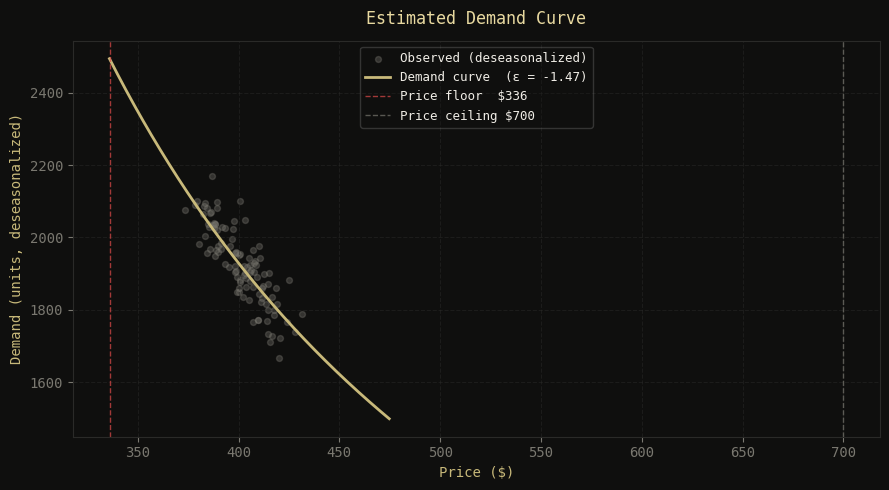

✓ Chart saved: demand_curve.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter actual data
ax.scatter(df["price"], df["qty_deseasoned"], alpha=0.35, s=18, color=MUTED, label="Observed (deseasonalized)")

# Fitted curve
p_range = np.linspace(df["price"].min() * 0.9, df["price"].max() * 1.1, 300)
q_fitted = np.exp(alpha + elasticity * np.log(p_range))
ax.plot(p_range, q_fitted, color=GOLD, lw=2, label=f"Demand curve  (ε = {elasticity:.2f})")

ax.axvline(PRICE_FLOOR,   color=DANGER, lw=1, ls="--", alpha=0.7, label=f"Price floor  ${PRICE_FLOOR:.0f}")
ax.axvline(PRICE_CEILING, color=MUTED,  lw=1, ls="--", alpha=0.7, label=f"Price ceiling ${PRICE_CEILING:.0f}")

ax.set_xlabel("Price ($)")
ax.set_ylabel("Demand (units, deseasonalized)")
ax.set_title("Estimated Demand Curve", color=GOLD2, pad=12)
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True)
plt.tight_layout()
plt.savefig("demand_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved: demand_curve.png")


## Step 4: Optimize price per period

For each future period, the notebook:
1. Applies the seasonal factor to scale expected demand
2. Finds the price **P\*** that maximizes expected profit:  
   `Profit(P) = (P - Cost) × Q(P) × SeasonalFactor`
3. Enforces floor and ceiling constraints

The result is a practical recommendation, not a commandment. If the market ignores it, the market is not defective. It is just doing market things.

In [6]:
def demand(price, sf=1.0):
    """Expected demand at a given price and seasonal factor."""
    return np.exp(alpha + elasticity * np.log(max(price, 1))) * sf

def profit(price, sf=1.0):
    """Expected profit at a given price and seasonal factor."""
    return (price - COST_PER_UNIT) * demand(price, sf)

def optimal_price(sf=1.0):
    """Find profit-maximizing price within floor/ceiling bounds."""
    result = minimize_scalar(
        lambda p: -profit(p, sf),
        bounds=(PRICE_FLOOR, PRICE_CEILING),
        method="bounded"
    )
    return round(result.x, 2)

# ── Generate forecast ────────────────────────────────────────
last_date = df["date"].max()
forecast_rows = []

for i in range(1, FORECAST_MONTHS + 1):
    fdate  = last_date + relativedelta(months=i)
    month  = fdate.month
    sf     = SEASONAL_FACTORS[month]
    p_opt  = optimal_price(sf)
    q_exp  = demand(p_opt, sf)
    rev    = p_opt * q_exp
    profit_exp = (p_opt - COST_PER_UNIT) * q_exp
    margin = (p_opt - COST_PER_UNIT) / p_opt

    forecast_rows.append({
        "Period":         fdate.strftime("%b %Y"),
        "Month":          month,
        "Seasonal Factor":sf,
        "Optimal Price":  p_opt,
        "Exp. Demand":    round(q_exp),
        "Exp. Revenue":   round(rev, 2),
        "Exp. Profit":    round(profit_exp, 2),
        "Gross Margin":   f"{margin:.1%}",
    })

forecast = pd.DataFrame(forecast_rows)
print("── 6-Month Pricing Forecast ────────────────────────────")
print(forecast.to_string(index=False))


── 6-Month Pricing Forecast ────────────────────────────
  Period  Month  Seasonal Factor  Optimal Price  Exp. Demand  Exp. Revenue  Exp. Profit Gross Margin
Jan 2025      1             0.82          700.0          694     485589.63    291353.78        60.0%
Feb 2025      2             0.85          700.0          719     503355.10    302013.06        60.0%
Mar 2025      3             0.93          700.0          787     550729.70    330437.82        60.0%
Apr 2025      4             0.97          700.0          821     574417.00    344650.20        60.0%
May 2025      5             1.00          700.0          846     592182.47    355309.48        60.0%
Jun 2025      6             1.04          700.0          880     615869.77    369521.86        60.0%


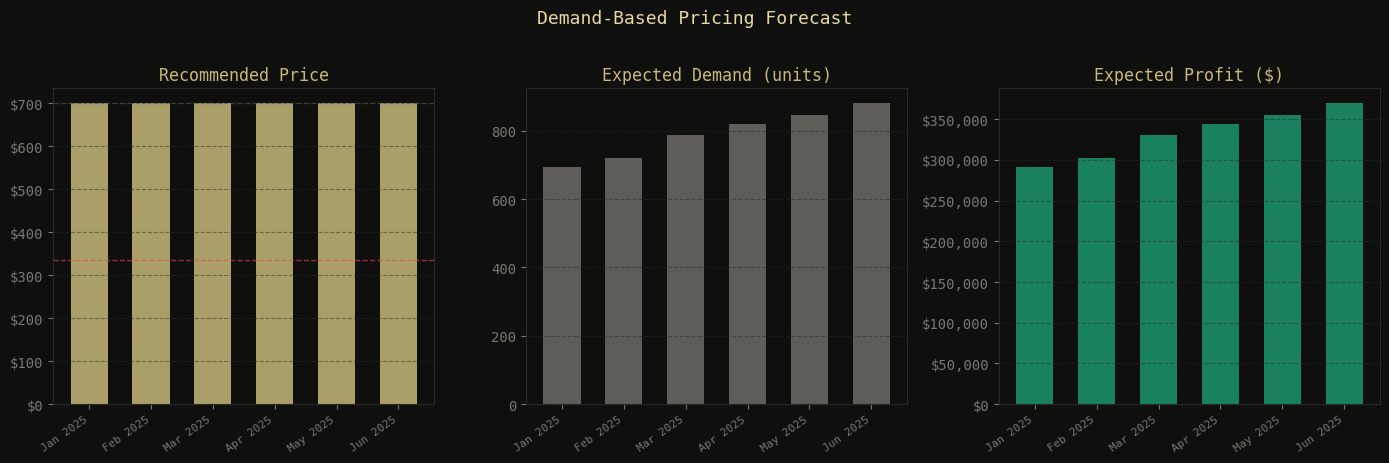

✓ Chart saved: pricing_forecast.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Demand-Based Pricing Forecast", color=GOLD2, fontsize=13, y=1.02)

periods = forecast["Period"]
x = np.arange(len(periods))

# Price
axes[0].bar(x, forecast["Optimal Price"], color=GOLD, alpha=0.85, width=0.6)
axes[0].axhline(PRICE_FLOOR,   color=DANGER, lw=1, ls="--", alpha=0.6)
axes[0].axhline(PRICE_CEILING, color=MUTED,  lw=1, ls="--", alpha=0.4)
axes[0].set_title("Recommended Price", color=GOLD)
axes[0].set_xticks(x); axes[0].set_xticklabels(periods, rotation=35, ha="right", fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

# Demand
axes[1].bar(x, forecast["Exp. Demand"], color=MUTED, alpha=0.75, width=0.6)
axes[1].set_title("Expected Demand (units)", color=GOLD)
axes[1].set_xticks(x); axes[1].set_xticklabels(periods, rotation=35, ha="right", fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))

# Profit
axes[2].bar(x, forecast["Exp. Profit"], color=GREEN, alpha=0.8, width=0.6)
axes[2].set_title("Expected Profit ($)", color=GOLD)
axes[2].set_xticks(x); axes[2].set_xticklabels(periods, rotation=35, ha="right", fontsize=8)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

for ax in axes:
    ax.grid(True, axis="y")
    ax.set_facecolor("#0f0f0e")

plt.tight_layout()
plt.savefig("pricing_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved: pricing_forecast.png")


## Step 5: Sensitivity analysis

Elasticity estimates are useful, but they are still estimates.

This table shows how the recommended price and expected profit change if elasticity is 20% higher or lower than estimated. It is a small stress test for the assumption doing most of the work, which is usually where the bodies are buried.

In [8]:
# Elasticity sensitivity across next month
next_sf    = SEASONAL_FACTORS[(last_date + relativedelta(months=1)).month]
e_variants = [elasticity * 0.8, elasticity, elasticity * 1.2]
labels     = ["Elasticity -20%", "Base estimate", "Elasticity +20%"]

print(f"Sensitivity analysis - next period (SF = {next_sf})")
print(f"{'Scenario':<22} {'Elasticity':>12} {'Opt. Price':>12} {'Exp. Demand':>14} {'Exp. Profit':>13}")
print("─" * 75)

for label, e in zip(labels, e_variants):
    # Temporarily override global elasticity for this calc
    def _demand(p, sf, _e=e): return np.exp(alpha + _e * np.log(max(p,1))) * sf
    def _profit(p, sf, _e=e): return (p - COST_PER_UNIT) * _demand(p, sf, _e)

    res = minimize_scalar(lambda p: -_profit(p, next_sf), bounds=(PRICE_FLOOR, PRICE_CEILING), method="bounded")
    p_  = round(res.x, 2)
    q_  = round(_demand(p_, next_sf))
    pr_ = round(_profit(p_, next_sf), 2)
    print(f"{label:<22} {e:>12.3f} ${p_:>11,.2f} {q_:>14,} ${pr_:>12,.2f}")

print("─" * 75)
print("\nKey insight: if true elasticity is higher than estimated, the model")
print("may be recommending prices that are too high. Validate against A/B test")
print("data when available.")


Sensitivity analysis - next period (SF = 0.82)
Scenario                 Elasticity   Opt. Price    Exp. Demand   Exp. Profit
───────────────────────────────────────────────────────────────────────────
Elasticity -20%              -1.178 $     700.00          4,778 $2,006,836.47
Base estimate                -1.473 $     700.00            694 $  291,353.78
Elasticity +20%              -1.767 $     644.85            116 $   42,480.04
───────────────────────────────────────────────────────────────────────────

Key insight: if true elasticity is higher than estimated, the model
may be recommending prices that are too high. Validate against A/B test
data when available.


## Step 6: Export results

The notebook exports the forecast, model summary, and cleaned input data to Excel.

This makes the output easier to inspect, share, audit, or attach to an email that begins with “per our previous discussion,” which is where optimism goes to die.

In [9]:
from pathlib import Path

output_path = Path("decaiq_pricing_forecast.xlsx")

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    forecast.to_excel(writer, sheet_name="Forecast", index=False)

    summary = pd.DataFrame({
        "Parameter":  ["Cost per unit", "Price floor", "Price ceiling", "Elasticity (ε)", "R²", "Data points", "Forecast months"],
        "Value":      [f"${COST_PER_UNIT:.2f}", f"${PRICE_FLOOR:.2f}", f"${PRICE_CEILING:.2f}",
                       f"{elasticity:.3f}", f"{r**2:.3f}", len(df), FORECAST_MONTHS],
    })
    summary.to_excel(writer, sheet_name="Model Summary", index=False)

    df.to_excel(writer, sheet_name="Input Data", index=False)

print(f"✓ Results exported: {output_path}")
print(f"  Sheets: Forecast · Model Summary · Input Data")


✓ Results exported: decaiq_pricing_forecast.xlsx
  Sheets: Forecast · Model Summary · Input Data


---

## What this model does and does not do

This notebook is meant to be transparent and useful. It is not meant to pretend away the hard parts of pricing.

**It does:**
- Estimate price elasticity from historical data
- Apply seasonal adjustments to forward-looking demand
- Recommend profit-maximizing prices within cost and ceiling constraints
- Run sensitivity analysis on the elasticity assumption
- Export results for review and reuse
- Flag weak model fit so nobody has to learn humility from a pricing mistake in production

**It does not:**
- Account for competitor pricing or channel pressure
- Handle inventory constraints
- Separate promotional effects from organic demand
- Distinguish between launch-phase and mature-product pricing dynamics
- Provide causal estimates

Correlation in price and volume data is not causation. It is still useful, but it should not be allowed to wear a lab coat unsupervised.

**Next steps to make this production-ready:**
1. Replace simulated data with actual transaction history
2. Tune `SEASONAL_FACTORS` using historical month-over-month patterns
3. Validate elasticity against controlled price tests where possible
4. Add competitor, promotion, inventory, and channel-pressure signals
5. Track recommendation outcomes over time so the workflow can improve instead of merely looking confident

---

Built by Rodrigo Celis-Duran as a TaskMarket example workflow.  
TaskMarket is being built for reusable work products, agent-ready services, and practical business automation.  
[linkedin.com/in/rodrigo-celis-duran-20243818a](https://linkedin.com/in/rodrigo-celis-duran-20243818a)  
[taskmarket.org](https://taskmarket.org)